# Insurance Cost Prediction with a Neural Network

## Project Objective
Build and train a neural network using Keras to predict medical insurance charges based on personal characteristics.

## Target Variable
- `charges`

## Problem Type
- Regression

In [1]:
import sys
print(sys.executable)

u:\insurance_nn_project\.venv\Scripts\python.exe


In [2]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [3]:
# Load the insurance dataset directly from the provided URL
df = pd.read_csv("https://raw.githubusercontent.com/TripleTen-DS/Dataset/refs/heads/main/insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# Data Exploration
df.shape
df.info()
df.isna().sum()
df.describe()
df.describe(include="object")

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


C:\Users\oramirez\AppData\Local\Temp\ipykernel_60832\3485209662.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


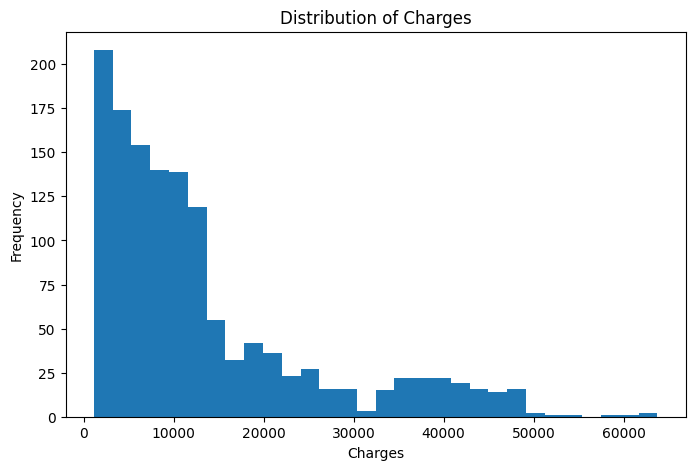

In [5]:
# plot targer distribution
plt.figure(figsize=(8,5))
plt.hist(df['charges'], bins=30)
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.title('Distribution of Charges')
plt.show()

In [6]:
# Disply statistics for the target vatiable  
df["charges"].describe()

count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64

## Initial Observations

- This dataset includes 1,338 insurance records and 7 total columns.
- No missing values were found, so no imputation is needed at this stage.
- The categorical input features are `sex`, `smoker`, and `region`.
- The numerical input features are `age`, `bmi`, and `children`.
- The target variable is `charges`, which makes this a regression problem because the model must predict a continuous numeric value.
- The distribution of `charges` is right-skewed, meaning most beneficiaries have lower charges, while a smaller group has much higher costs.
- Since `charges` spans a wide range of values, scaling the target may improve training stability for the neural network.

## Data Preprocessing

Before training the neural network, the dataset must be prepared in a format the model can use.

The categorical variables (`sex`, `smoker`, and `region`) will be converted into numerical form using one-hot encoding.  
The numerical variables (`age`, `bmi`, and `children`) will be scaled so they are on similar ranges, which helps neural networks train more effectively.

The dataset will be split into training and testing sets before fitting the preprocessing steps in order to avoid data leakage.  
The target variable, `charges`, will also be scaled because its values span a wide range, which can make training less stable.

In [7]:
# Create the feature matrix by dropping the target column
X = df.drop ("charges", axis=1)

# Create the target vector
y = df["charges"]

In [8]:
# List the categorical columns that need one hot encoding
categorical_cols = ["sex", "smoker", "region"]

# List of numerical columns that will be scaled
numerical_cols = ["age", "bmi", "children"]

# split data into training and test sets
# 80% of the data will be userd for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# create the one hot encoder
# sparse_output=False returns a NumPy array instead of a sparse matrix
# handle_unknown="ignore" prevents errors if a category appears in test data that was not seen in training 
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

# fit the encoder on the training categorical data and transform it 
X_train_cat = encoder.fit_transform(X_train[categorical_cols])

# transform the test categorical data using the already fitted encoder
X_test_cat = encoder.transform(X_test[categorical_cols])

In [9]:
# create the scaler for numerical features
feature_scaler = StandardScaler()

# fit the scaler on training numerical data and transform it 
X_train_num = feature_scaler.fit_transform(X_train[numerical_cols])

#transform the tests numerical data using the already fitted scaler
X_test_num = feature_scaler.transform(X_test[numerical_cols])

# combine the scaled numerical feature and encode categorical features
X_train_processed = np.concatenate([X_train_num, X_train_cat], axis=1)
X_test_processed = np.concatenate([X_test_num, X_test_cat], axis=1)

# Create scaler for target variable
target_scaler = StandardScaler()
y_train_scaled = target_scaler.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = target_scaler.transform(y_test.values.reshape(-1, 1))

In [10]:
# print shapes of the processed data
print("X_train_processed shape:", X_train_processed.shape)
print("X_test_processed shape:", X_test_processed.shape)
print("y_train_scaled shape:", y_train_scaled.shape)
print("y_test_scaled shape:", y_test_scaled.shape)

X_train_processed shape: (1070, 11)
X_test_processed shape: (268, 11)
y_train_scaled shape: (1070, 1)
y_test_scaled shape: (268, 1)


## Preprocessing Observations

- The input features were separated into categorical and numerical groups.
- One-hot encoding was used for categorical columns so the neural network could work with them as numeric inputs.
- Standardization was applied to numerical features so that the variables would be on similar scales.
- The target variable, `charges`, was also scaled to improve training stability.
- The encoder and scalers were fit only on the training data to prevent data leakage.
- After preprocessing, the feature matrices were ready to be used as input for the neural network.

## Building the First Neural Network

The first neural network will be kept simple so it can serve as a baseline model.

The model will use:
- two hidden dense layers with ReLU activation
- one output neuron for predicting a continuous target value
- Adam optimizer for training
- mean squared error (MSE) as the loss function
- mean absolute error (MAE) as an evaluation metric

This baseline model will allow us to evaluate initial performance before experimenting with other architectures or hyperparameters.

In [12]:
# Build a Simple baseline neural network model 
model = keras.Sequential([
    # First hidden layer 
    layers.Dense(64, activation="relu", input_shape=(X_train_processed.shape[1],)),

    # Second Hidden Layer
    layers.Dense(32, activation="relu"),

    #output layer: 1 neuron becouse we are predicting one continuous value
    layers.Dense(1)
])

u:\insurance_nn_project\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# compile the model 
# Adam is a dtong default optomizer
# MSE is a standard regression loss
# MAE is easier to interpret as an average pediction error 
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [14]:
# Display the model architecture
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,881 (11.25 KB)

 Trainable params: 2,881 (11.25 KB)

 Non-trainable params: 0 (0.00 B)

## Training the Model

The model will be trained using the processed training data.

A validation split will be used during training so that training and validation performance can be compared.  
Early stopping will also be used to stop training if validation loss stops improving.

This helps reduce overfitting and keeps the best version of the model.

In [15]:
# import early stoppping to hellp prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping

In [16]:
# stop training if valikdation loss does not improve for 10 epochs
# restore_best_weights=True keeps the best version of the model 
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [17]:
# train the model on the processed training data
history = model.fit(
    X_train_processed,
    y_train_scaled,
    validation_split=0.2,
    epochs=100,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.8440 - mae: 0.6632 - val_loss: 0.6261 - val_mae: 0.5637
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4566 - mae: 0.4746 - val_loss: 0.3140 - val_mae: 0.3746
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2763 - mae: 0.3758 - val_loss: 0.2111 - val_mae: 0.2848
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2135 - mae: 0.3040 - val_loss: 0.1787 - val_mae: 0.2498
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1853 - mae: 0.2782 - val_loss: 0.1662 - val_mae: 0.2335
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1708 - mae: 0.2565 - val_loss: 0.1545 - val_mae: 0.2189
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1650 - mae: 0.2452 - val_loss: 0.1523 - val_mae: 0.2730
Epoch 8/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1584 - mae: 0.2485 - val_loss: 0.1460 - val_mae: 0.2552
Epoch 9/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.151

In [18]:
# show which values were tracked during training
history.history.keys()

dict_keys(['loss', 'mae', 'val_loss', 'val_mae'])

In [19]:
# Print final training and validation metrics
print("Final training loss:", history.history["loss"][-1])
print("Final validation loss:", history.history["val_loss"][-1])
print("Final training MAE:", history.history["mae"][-1])
print("Final validation MAE:", history.history["val_mae"][-1])

Final training loss: 0.129075288772583
Final validation loss: 0.14555789530277252
Final training MAE: 0.22044965624809265
Final validation MAE: 0.23896342515945435


## Initial Training Observations

The baseline neural network was trained using a validation split and early stopping.

This allows training performance and validation performance to be compared during learning.  
The results from this first model will be used to determine whether the network is learning well, underfitting, or overfitting before making further adjustments.

## Interpretation of Baseline Training Results

The baseline neural network trained successfully and stopped early, likely because validation loss stopped improving.

The final training and validation metrics were relatively close:
- Training loss: 0.1291
- Validation loss: 0.1456
- Training MAE: 0.2204
- Validation MAE: 0.2390

These results suggest that the model is learning reasonably well and does not show strong signs of overfitting.  
Because the training and validation metrics are similar, the model appears fairly well-balanced at this stage.

However, these values are still based on the scaled target variable, so the next step is to evaluate the model on the test set and convert predictions back to the original dollar scale for real-world interpretation.

## Training History Visualization

To better understand the learning process, the training and validation loss curves will be plotted.

These plots help show whether the model improved steadily during training and whether there are signs of underfitting or overfitting.


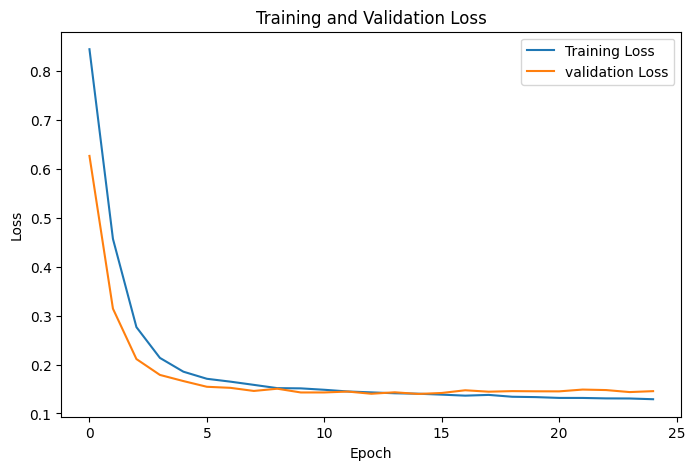

In [20]:
# Plot training loss and validation loss over epochs
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"],label=["Training Loss"])
plt.plot(history.history["val_loss"], label=["validation Loss"])

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()